In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import time
import sys
import importlib
from pathlib import Path

for project_root in (Path.cwd(), Path.cwd().parent):
    if (project_root / 'binary_sync').is_dir():
        sys.path.insert(0, str(project_root))
        break

# Clear previously imported project modules so notebook cells use current source.
for module_name in list(sys.modules):
    if module_name == 'binary_sync' or module_name.startswith('binary_sync.'):
        del sys.modules[module_name]
importlib.invalidate_caches()

from matplotlib.lines import Line2D
from binary_sync.model import sample_instance, Graph
from binary_sync.bp import bp_corr2
from binary_sync.spectral import spectral_corr2
from binary_sync.low_degree import low_degree_corr2 as low_degree_corr
from binary_sync.low_degree import low_degree_weights as compute_low_degree_weights, print_low_degree_weights
from binary_sync.percolation import estimate_percolation_bound
from binary_sync.reporting import format_estimate

## E-R graph tests


In [7]:
def draw_graph(graph, source, target, ax=None, seed=0, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    nx_graph = nx.MultiGraph()
    nx_graph.add_nodes_from(graph.nodes)
    for edge_id, edge in enumerate(graph.edges):
        nx_graph.add_edge(edge.u, edge.v, key=edge_id)
    positions = nx.spring_layout(nx_graph, seed=seed)
    nx.draw_networkx_edges(nx_graph, positions, ax=ax, width=1.8, edge_color="gray")
    ordinary_nodes = [node for node in graph.nodes if node not in {source, target}]
    nx.draw_networkx_nodes(nx_graph, positions, nodelist=ordinary_nodes, ax=ax, node_size=700, node_color="lightblue", edgecolors="black")
    nx.draw_networkx_nodes(nx_graph, positions, nodelist=[source], ax=ax, node_size=850, node_color="mediumseagreen", edgecolors="black", linewidths=2)
    nx.draw_networkx_nodes(nx_graph, positions, nodelist=[target], ax=ax, node_size=850, node_color="darkorange", edgecolors="black", linewidths=2)
    labels = {node: ("s" if node == source else "t" if node == target else str(node)) for node in graph.nodes}
    nx.draw_networkx_labels(nx_graph, positions, labels=labels, ax=ax, font_size=10)
    if title is not None:
        ax.set_title(title)
    ax.set_axis_off()
    return ax

In [8]:
def clique_graph(n, p):
    graph = Graph()
    for u in range(n):
        for v in range(u + 1, n):
            graph.add_edge(u, v, p)
    return graph

clique = clique_graph(5, 0.2)
s, t = 0, 4
print(f"Clique graph created with {len(clique.nodes)} nodes and {len(clique.edges)} edges")

Clique graph created with 5 nodes and 10 edges


<Axes: title={'center': 'Clique Graph'}>

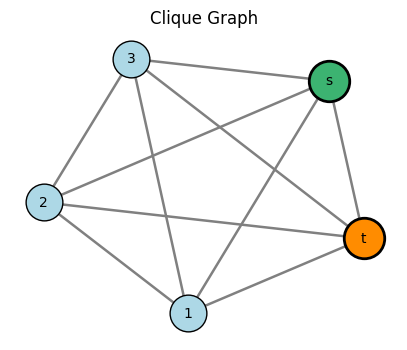

In [9]:
draw_graph(clique, s, t, title="Clique Graph")

In [10]:
start = time.perf_counter()
result_bp_clique = bp_corr2(clique, s, t, n_samples=1000, seed=1, init="random")
runtime_bp_clique = time.perf_counter() - start

start = time.perf_counter()
result_spectral_clique = spectral_corr2(clique, s, t, alg="naive", n_samples=5000, seed=1)
runtime_spectral_clique = time.perf_counter() - start

start = time.perf_counter()
result_low_degree_clique = low_degree_corr2(clique, 4, s, t)
runtime_low_degree_clique = time.perf_counter() - start

print(f"BP: {format_estimate(result_bp_clique['corr2'], result_bp_clique['standard_error'])} (runtime: {runtime_bp_clique:.4f} s)")
print(f"Spectral: {format_estimate(result_spectral_clique['corr2'], result_spectral_clique['standard_error'])} (runtime: {runtime_spectral_clique:.4f} s)")
print(f"Low-degree: {format_estimate(result_low_degree_clique)} (runtime: {runtime_low_degree_clique:.4f} s)")

BP: estimate=0.503949, 95% CI=[0.450963, 0.556936] (runtime: 7.0138 s)
Spectral: estimate=0.419904, 95% CI=[0.392541, 0.447267] (runtime: 0.1657 s)
Low-degree: estimate=0.532037, 95% CI=[0.532037, 0.532037] (runtime: 0.0022 s)


In [5]:
weights = compute_low_degree_weights(clique, s, t, p=0.2, degree=4)
print_low_degree_weights(clique, weights)

Edge IDs:
  0: (0, 1)
  1: (0, 2)
  2: (0, 3)
  3: (0, 4)
  4: (1, 2)
  5: (1, 3)
  6: (1, 4)
  7: (2, 3)
  8: (2, 4)
  9: (3, 4)

Low-degree weights:
  basis=(3,), edges=[(0, 4)], weight=0.502555
  basis=(0, 6), edges=[(0, 1), (1, 4)], weight=0.171511
  basis=(1, 8), edges=[(0, 2), (2, 4)], weight=0.171511
  basis=(2, 9), edges=[(0, 3), (3, 4)], weight=0.171511
  basis=(0, 4, 8), edges=[(0, 1), (1, 2), (2, 4)], weight=0.060660
  basis=(0, 5, 9), edges=[(0, 1), (1, 3), (3, 4)], weight=0.060660
  basis=(1, 4, 6), edges=[(0, 2), (1, 2), (1, 4)], weight=0.060660
  basis=(1, 7, 9), edges=[(0, 2), (2, 3), (3, 4)], weight=0.060660
  basis=(2, 5, 6), edges=[(0, 3), (1, 3), (1, 4)], weight=0.060660
  basis=(2, 7, 8), edges=[(0, 3), (2, 3), (2, 4)], weight=0.060660
  basis=(0, 1, 3, 4), edges=[(0, 1), (0, 2), (0, 4), (1, 2)], weight=-0.049658
  basis=(0, 2, 3, 5), edges=[(0, 1), (0, 3), (0, 4), (1, 3)], weight=-0.049658
  basis=(0, 4, 7, 9), edges=[(0, 1), (1, 2), (2, 3), (3, 4)], weight=0.0063

### Averaged Erdős–Rényi benchmark


In [11]:
def generate_er_graph(n, prob, p, rng=None):
    if not 0.0 <= prob <= 1.0:
        raise ValueError("prob must lie in [0, 1].")
    if not 0.0 <= p < 1.0:
        raise ValueError("p must lie in [0, 1).")
    if rng is None:
        rng = np.random.default_rng()
    graph = Graph()
    for vertex in range(n):
        if hasattr(graph, "add_node"):
            graph.add_node(vertex)
        else:
            graph._node_set.add(vertex)
            graph.nodes.append(vertex)
    for u in range(n):
        for v in range(u + 1, n):
            if rng.random() < prob:
                graph.add_edge(u, v, p)
    return graph

In [12]:
n_er = 4
prob_er = 0.3
edge_noise_p = 0.2
n_graphs_er = 100
n_samples_er = 1000
source_er, target_er = 0, n_er - 1
rng_er = np.random.default_rng(20260815)

er_performance = {"BP": [], "Spectral": [], "Low-degree": [], "Percolation": []}
for _ in range(n_graphs_er):
    er_graph = generate_er_graph(n_er, prob_er, edge_noise_p, rng=rng_er)
    bp_result = bp_corr2(er_graph, source_er, target_er, n_samples=n_samples_er, seed=int(rng_er.integers(2**32)), init="random")
    spectral_result = spectral_corr2(er_graph, source_er, target_er, alg="naive", n_samples=n_samples_er, seed=int(rng_er.integers(2**32)))
    low_degree_result = low_degree_corr2(er_graph, 6, source_er, target_er)
    percolation_result = estimate_percolation_bound(er_graph, source_er, target_er, n_samples=n_samples_er, seed=int(rng_er.integers(2**32)))
    er_performance["BP"].append(bp_result["corr2"])
    er_performance["Spectral"].append(spectral_result["corr2"])
    er_performance["Low-degree"].append(low_degree_result)
    er_performance["Percolation"].append(percolation_result["bound"])

print(f"ER benchmark: n={n_er}, edge probability={prob_er}, noise p={edge_noise_p}, graph instances={n_graphs_er}")
for method, values in er_performance.items():
    values = np.asarray(values, dtype=float)
    mean = values.mean()
    standard_error = values.std(ddof=1) / np.sqrt(n_graphs_er)
    print(f"{method}: {format_estimate(mean, standard_error)}")

ER benchmark: n=4, edge probability=0.3, noise p=0.2, graph instances=100
BP: estimate=0.148096, 95% CI=[0.113316, 0.182876]
Spectral: estimate=0.135738, 95% CI=[0.102908, 0.168567]
Low-degree: estimate=0.147531, 95% CI=[0.113390, 0.181673]
Percolation: estimate=0.151180, 95% CI=[0.115933, 0.186427]
